## Basic plotting of regional MPAS grid using `uxarray` and `matplotlib` (Use environment `NPL 2025b`)

This notebook shows how to easily plot a regional MPAS mesh. Make sure you use the environment `NPL 2025b`

In [1]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import uxarray as ux

In [2]:
# Set location of your *grid.nc and *static.nc files. For this plot we will show terrain from the static files
grid_file = "../rundir_3km/x1.427829.grid.valpo.nc"
static_file = "../rundir_3km/x1.427829.static.valpo.nc"
ds = ux.open_dataset(grid_file,static_file,decode_times=False)

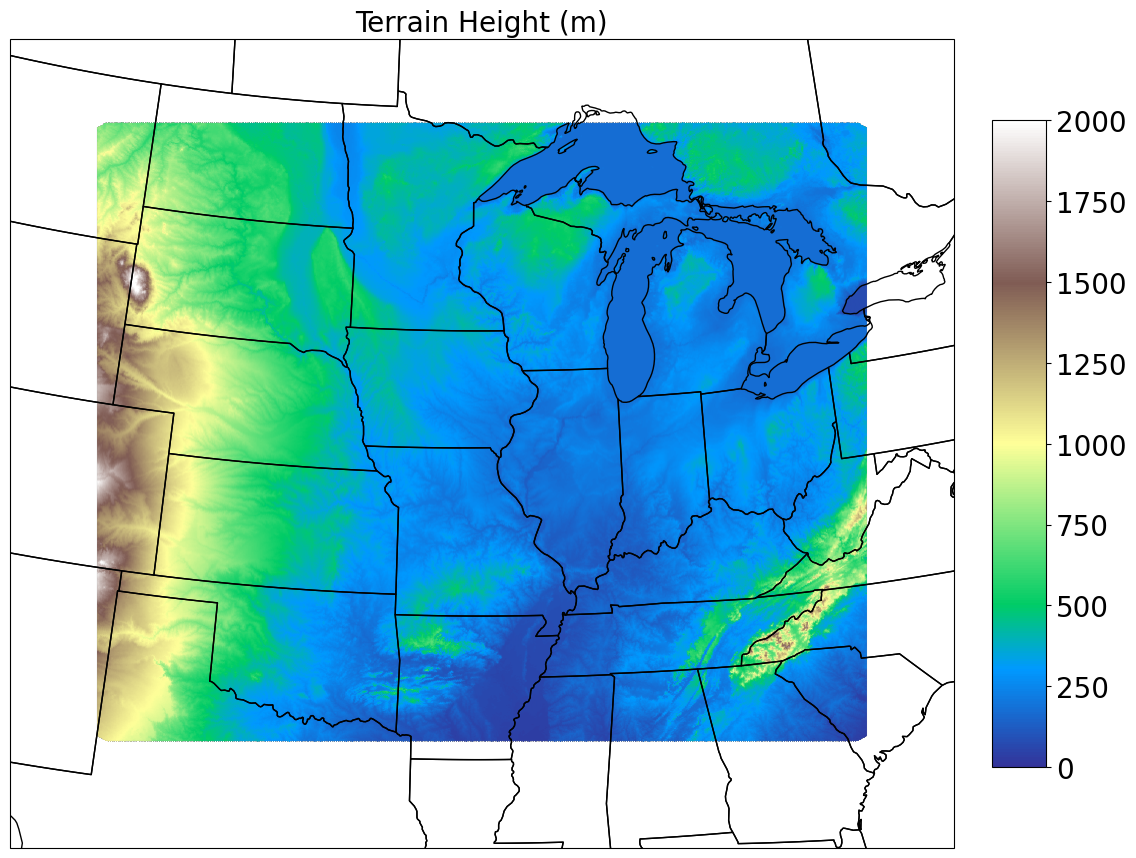

In [3]:
# Set up what projection and extent you want for your regional mesh
projection = ccrs.LambertConformal(central_longitude=-92.0,central_latitude=41.0,standard_parallels=(30.0,60.0))
fig, ax = plt.subplots(figsize=(16.67,10.5),subplot_kw={"projection": projection},facecolor="w")
ax.set_extent([-105,-79,30,50],crs=ccrs.PlateCarree())

raster = ds["ter"].to_raster(ax=ax)
im = ax.imshow(raster,origin="lower",extent=ax.get_xlim() + ax.get_ylim(),cmap="terrain",zorder=1,vmin=0,vmax=2000)
ax.add_feature(cfeature.COASTLINE.with_scale("50m"),linewidth=1,edgecolor="black")
ax.add_feature(cfeature.STATES.with_scale("50m"),linewidth=1,edgecolor="black")

cbar = fig.colorbar(im,ax=ax,orientation="vertical",pad=0.03,shrink=0.8,aspect=12)
cbar.ax.tick_params(labelsize=20)
ax.set_title("Terrain Height (m)",fontsize=20)

#plt.savefig("valpo_3km_domain.jpg", bbox_inches="tight", dpi=300)
plt.show()